# NIFH DIAZATROPS DATA SET FORMATTING
This notebook aims to explore and analyze the data from the 4 datasets with focus on the nifh gene data sheet in .xls file.

The NiFH gene values here are volumetric and not depth integrated.

All files go through the same process more or less. First they are opened and basic data is printed. Then I use a function that encapsulated most of common preprocessing logic to remove extra columns, convert object columns to numbers and round the coordinates. 

If needed columns are renamed and small adjustments are made. 

In [ ]:
import sys
print(sys.executable)

In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

There are some files that need to be present for this notebook to work:
- ***./csv/nifh/DiazotrophsDatabase-20240109_nifh.csv***
- ***./csv/nifh/MAREDAT_diazotroph_nifh.csv***
- ***./csv/nifh/Tang_GeophysicalResLett_2019_Data_nifh.csv***
- ***./csv/nifh/Shiozaki_NatGeosc_2020_Data_nifh.csv***

Each takes the data from the nifh_gene sheet of the corresponding exel file that I export as a csv file in order to be processed using pandas. If you clone the repo
they should be there already.

Some common and useful functions are separated into a .py file. Then they are imported here.

In [3]:
from parula_diy import parula_map

from format import removeEmptyRows, removeRed, objToNum, roundCoord, setND, prePrNifh
from visualize import plotColsOnMap, histCols

from var import cordinates_cols

There is a list of columns we actually want to keep in the final set in order to predict them. Other columns are not needed for this project and can be removed.

In [4]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]

#set to true if want to impute missing values with random separately and then join together.
imputeRandom=False

#final data columns that we intend to keep
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

# First dataset
This dataset is from the paper [Global oceanic diazotroph database version 2 and
elevated estimate of global oceanic N2 fixation](https://essd.copernicus.org/articles/15/3673/2023/essd-15-3673-2023-assets.html). (Shao, Xu, Luo)

In [5]:
#we want to remember which columns here to show
dzdb_cols = ['Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

#the dataset is opened
dzdb_2024_nifh = pd.read_csv(
    "../csv/nifh/DiazotrophsDatabase-20240109_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)

#we rename the mismatched column to match the other datasets
rename_map = {"Total UCYN-A nifH Gene (x106 copies m-3)":"UCYN-A nifH Gene (x106 copies m-3)"}
dzdb_2024_nifh.rename(columns=rename_map, inplace=True)

#basic data is printed
print(dzdb_2024_nifh.info())

<class 'pandas.DataFrame'>
RangeIndex: 5580 entries, 0 to 5579
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   SOURCE: Related article or authors                         143 non-null    str    
 1   METHODS:                  Sampling/Analysis                5580 non-null   str    
 2   DATE (yyyy-mm-dd)                                          5580 non-null   str    
 3   LATITUDE                                                   5580 non-null   float64
 4   LONGITUDE                                                  5580 non-null   float64
 5   DEPTH (m)                                                  5580 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)                  4515 non-null   str    
 7   UCYN-A1 nifH Gene (x106 copies m-3)                        4721 non-null   str    
 8   UCYN-A2/A3/A4 nifH 

Imputing ND values with a constant -1000.0


/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


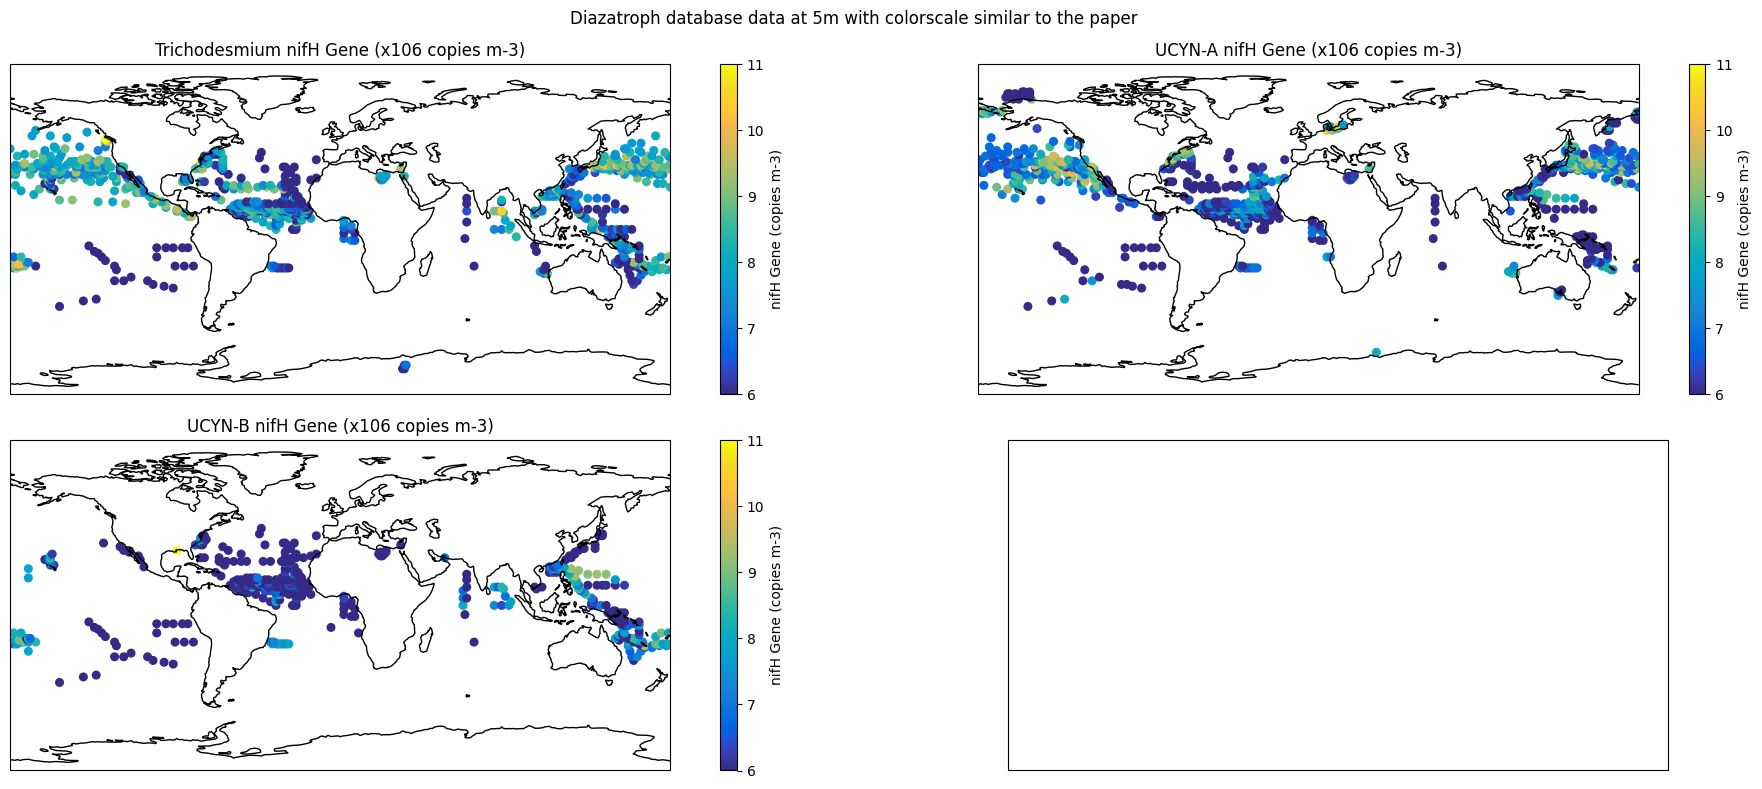

,LONGITUDE,LATITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,4886.000000,4886.000000,4886.000000,3.640000e+03,4149.000000,3485.000000
mean,-26.506345,14.839337,50.312116,6.247234e+04,92.187417,496.007185
std,128.621464,24.052948,70.162223,3.206039e+06,2142.753181,16669.974322
min,-180.000000,-76.000000,0.000000,-1.000000e+03,-1000.000000,-1000.000000
25%,-158.000000,5.000000,5.000000,8.575000e-02,0.000000,0.000000
50%,-54.000000,21.000000,25.000000,2.266000e+00,1.100000,0.426000
75%,117.000000,27.000000,80.000000,3.708825e+01,37.289800,6.178000
max,187.000000,75.000000,1700.000000,1.900000e+08,99700.000000,898000.000000


In [6]:
dzdb_2024_nifh_final = prePrNifh(df=dzdb_2024_nifh, y_col=bact_cols, random=imputeRandom)

#we also want to plot the contents of the dataset on the map, which we can do now as all data is numeric
plotColsOnMap(
    bact_cols,dzdb_2024_nifh_final,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Diazatroph database data at 5m with colorscale similar to the paper",
    s=30
)

dzdb_2024_nifh_final.describe()

In [7]:
dzdb_2024_nifh_final.info()

<class 'pandas.DataFrame'>
Index: 4886 entries, 0 to 5577
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  4886 non-null   int64  
 1   LATITUDE                                   4886 non-null   int64  
 2   DEPTH (m)                                  4886 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  3640 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         4149 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         3485 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 267.2 KB


# Second dataset
This is the dataset from the  [Database of diazotrophs in global ocean: abundance, biomass and nitrogen fixation rates](https://doi.pangaea.de/10.1594/PANGAEA.774851)

In [8]:
maredat_cols =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)"]

#here we open the dataset of the other database for cell count
maredat_nifh = pd.read_csv(
    "../csv/nifh/MAREDAT_diazotroph_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)

print(maredat_nifh.info())
maredat_nifh.head()

<class 'pandas.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 35 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    825 non-null    str    
 1   SOURCE: Related article                                         878 non-null    str    
 2   METHODS:                  Sampling/Analysis                     921 non-null    str    
 3   DATE (yyyy-mm-dd)                                               921 non-null    str    
 4   LATITUDE                                                        921 non-null    float64
 5   LONGITUDE                                                       921 non-null    float64
 6   DEPTH (m)                                                       921 non-null    int64  
 7   Trichodesmium nifH Gene (x106 copies m-3)                       

,SOURCE: Data,SOURCE: Related article,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),...,Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),Chlorophyll (mg m-3),Notes,Gamma A nifH Gene (x106 copies/m3),Gamma P nifH Gene (x106 copies/m3),CIII nifH Gene (x106 copies/m3)
0,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-10-31,-9.00,-136.86,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-03,-11.51,-134.35,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-04,-13.31,-132.39,70,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-05,-15.20,-130.20,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-06,-16.87,-128.38,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Imputing ND values with a constant -1000.0


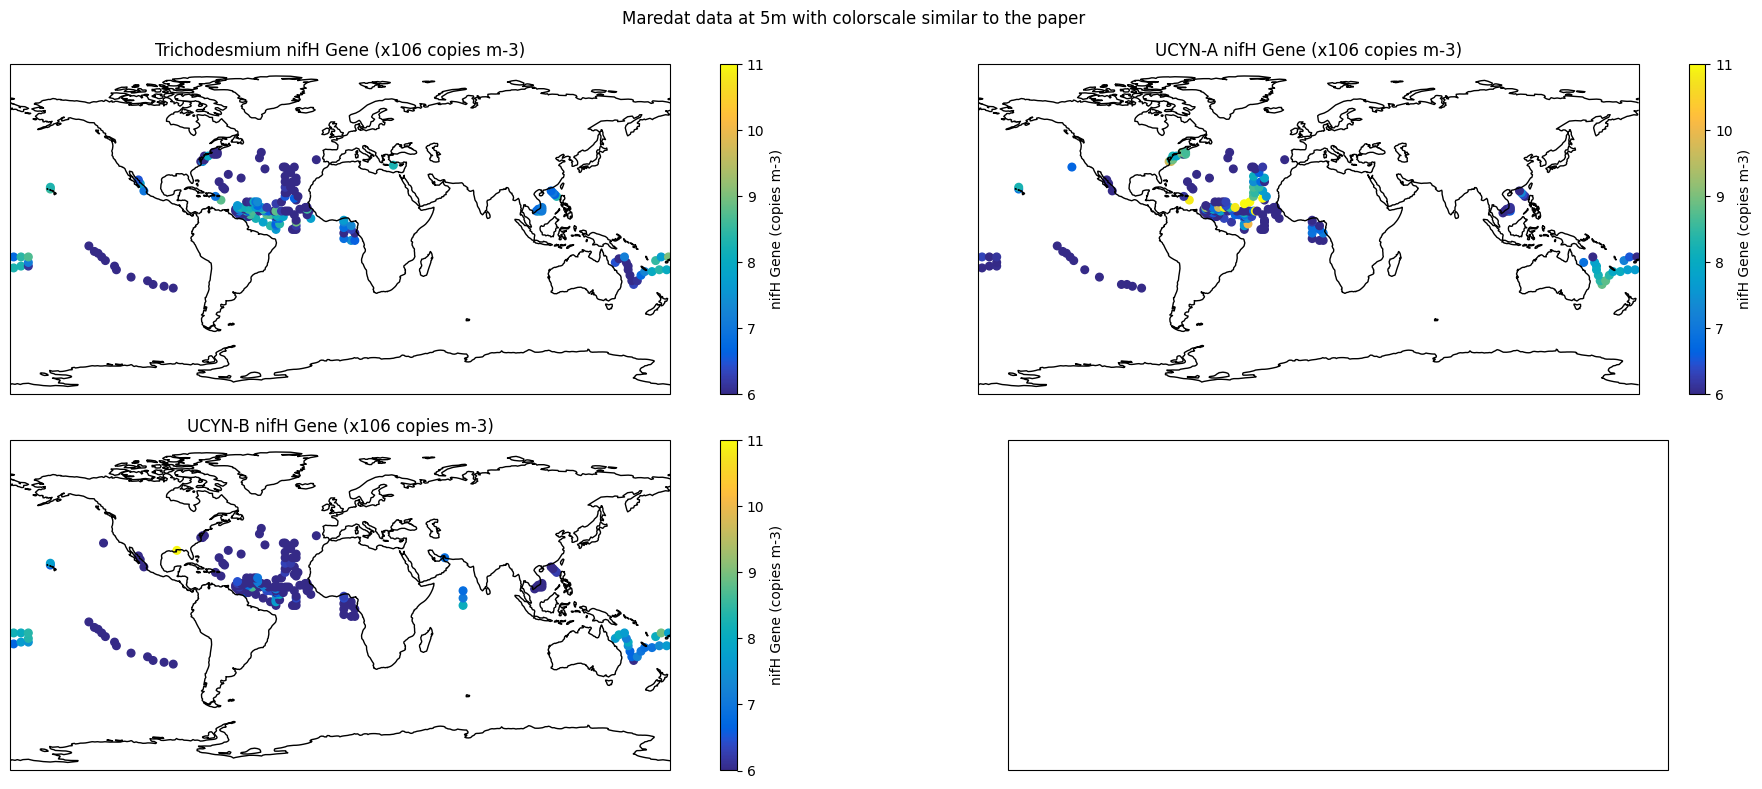

,LONGITUDE,LATITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,851.000000,851.000000,851.000000,759.000000,7.710000e+02,795.000000
mean,-7.861340,7.177438,61.032902,86.870968,2.298771e+04,2015.057620
std,103.604211,17.875524,114.467335,339.894468,2.620895e+05,34127.777036
min,-178.000000,-32.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,-56.000000,0.000000,5.000000,0.010000,0.000000e+00,0.000000
50%,-35.000000,10.000000,30.000000,0.868300,1.000000e-02,0.010000
75%,108.000000,19.000000,80.000000,16.620600,1.142735e+01,1.979950
max,179.000000,42.000000,1700.000000,6266.844800,4.810000e+06,898000.000000


In [9]:
maredat_nifh_final = prePrNifh(maredat_nifh,y_col=bact_cols , random=imputeRandom)

#the points in the dataset are plotted on the map
plotColsOnMap(
    bact_cols, maredat_nifh_final,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Maredat data at 5m with colorscale similar to the paper",
    s=30
)

maredat_nifh_final.describe()

In [10]:
maredat_nifh_final.info()

<class 'pandas.DataFrame'>
Index: 851 entries, 0 to 920
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  851 non-null    int64  
 1   LATITUDE                                   851 non-null    int64  
 2   DEPTH (m)                                  851 non-null    int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  759 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-3)         771 non-null    float64
 5   UCYN-B nifH Gene (x106 copies m-3)         795 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 46.5 KB


# Third dataset

This is an additional dataset that is meant to contain more diverse data than the first 2. It is based on Tang [Data-Driven Modeling of the Distribution of Diazotrophs in the Global Ocean](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2019GL084376)

In [11]:
tang_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

tang_nifh = pd.read_csv(
    "../csv/nifh/Tang_GeophysicalResLett_2019_Data_nifh.csv", 
    keep_default_na=False, 
    na_values=[""]
)

print(tang_nifh.info())

mask = tang_nifh["DEPTH (m)"]=="0-1 m"
tang_nifh.loc[mask, "DEPTH (m)"]="0"


<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 43 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    37 non-null     str    
 1   METHODS:                  Sampling/Analysis                     2006 non-null   str    
 2   DATE (mm/dd/yyyy)                                               2006 non-null   str    
 3   LATITUDE                                                        2006 non-null   float64
 4   LONGITUDE                                                       2006 non-null   float64
 5   DEPTH (m)                                                       2006 non-null   str    
 6   Trichodesmium nifH Gene (x106 copies m-3)                       1540 non-null   str    
 7   Trichodesmium Biomass Conversion factor (mg C/106 nifH copies)

In [12]:
#saved for a plot where only tang data is used
tang_nifh_rand = prePrNifh(tang_nifh, y_col=bact_cols)
tang_nifh_rand.to_csv("../csv/features/tang.csv",index=False)

#actually going to bacterial data
tang_nifh_final=prePrNifh(tang_nifh,y_col=bact_cols , random=imputeRandom)

Imputing ND values with uniform random distribution between 1e-06 and 0.01
Imputing ND values with a constant -1000.0


/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


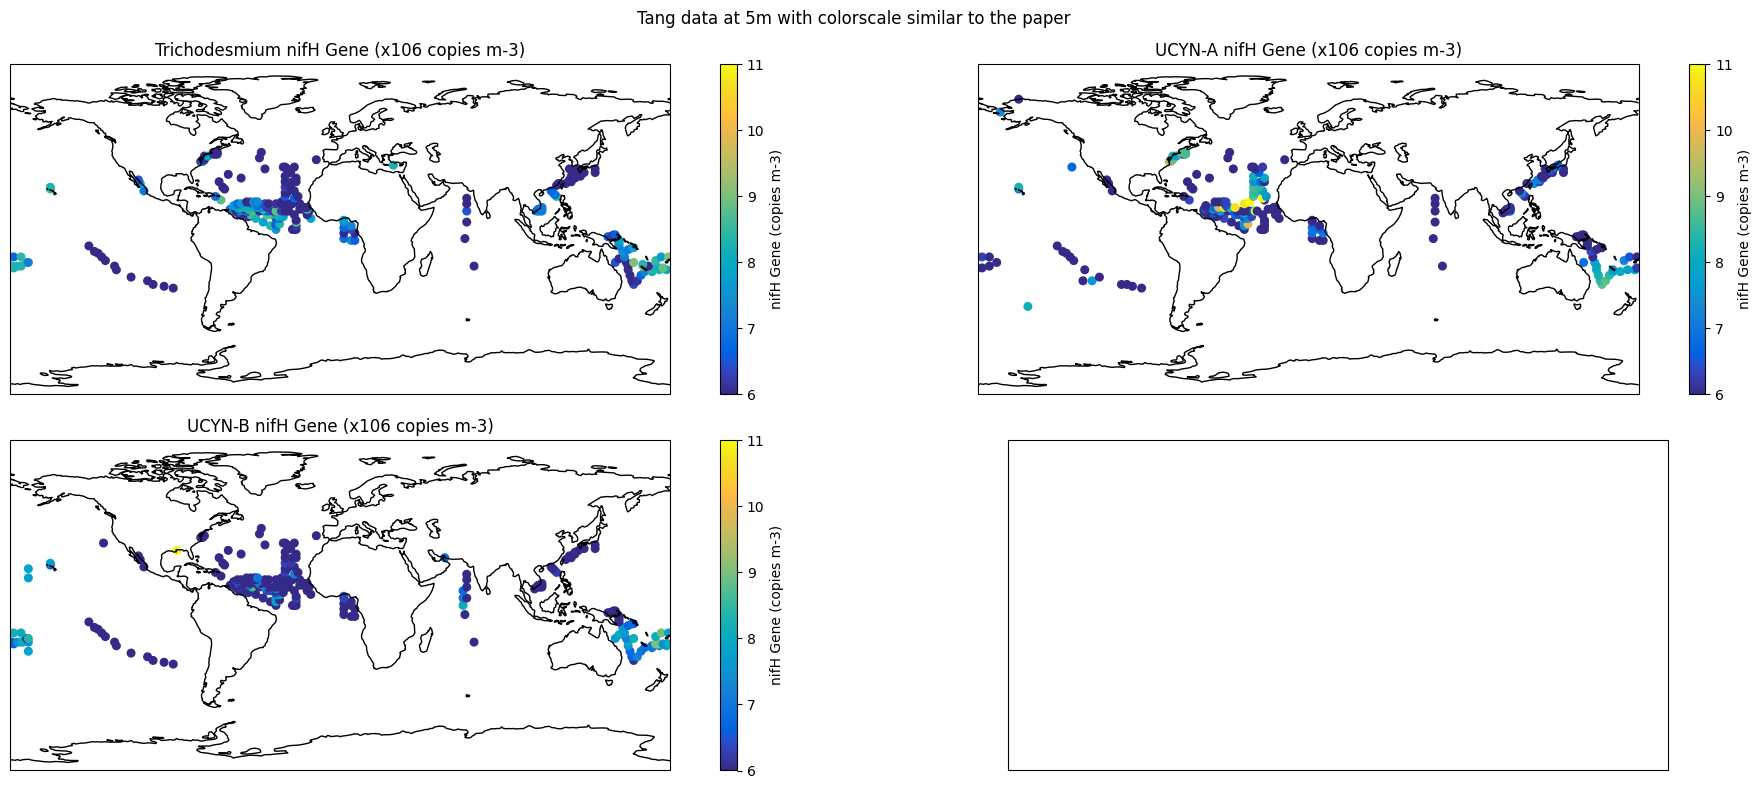

,LONGITUDE,LATITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,1820.000000,1820.000000,1820.000000,1539.000000,1.733000e+03,1563.000000
mean,8.761538,10.097253,52.439011,-106.694337,6.800316e+03,848.428508
std,123.813344,24.832654,88.282769,620.393123,1.365422e+05,24364.032796
min,-179.000000,-42.000000,0.000000,-1000.000000,-1.000000e+03,-1000.000000
25%,-100.000000,-15.000000,5.000000,0.000000,0.000000e+00,0.000000
50%,-25.000000,12.000000,27.000000,0.430000,0.000000e+00,0.010000
75%,126.000000,23.000000,75.000000,10.281000,3.007700e+00,1.723650
max,179.000000,74.000000,1700.000000,9413.540000,4.810000e+06,898000.000000


In [13]:
plotColsOnMap(
    bact_cols,tang_nifh_final,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Tang data at 5m with colorscale similar to the paper",
    s=30
)

tang_nifh_final.describe()

In [14]:
tang_nifh_final.info()

<class 'pandas.DataFrame'>
Index: 1820 entries, 0 to 2005
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  1820 non-null   int64  
 1   LATITUDE                                   1820 non-null   int64  
 2   DEPTH (m)                                  1820 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  1539 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         1733 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1563 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 99.5 KB


# Fourth dataset for UCYN A

In [15]:
#we keep only the necessary columns and convert them to numbers
shio_keep = ["Longitude","Latitude", "Maximum abundance of UCYN-A"]
shio_y = ["UCYN-A nifH Gene (x106 copies m-3)"]
shio_cord = ["LONGITUDE","LATITUDE"]


shio_nifh = pd.read_csv(
    "../csv/nifh/Shiozaki_NatGeosc_2020_Data_nifh.csv",
    keep_default_na=False, 
    na_values=[""]
)
shio_nifh.drop(0,inplace=True)
print(shio_nifh.info())
shio_nifh.head()

#rename the columns
rename_shio = {"Longitude":"LONGITUDE","Latitude":"LATITUDE","Maximum abundance of UCYN-A":"UCYN-A nifH Gene (x106 copies m-3)"}
shio_nifh.rename(columns=rename_shio, inplace=True)

shio_final=prePrNifh(shio_nifh,random=imputeRandom, y_col=shio_y, cord=shio_cord)

#scale adjustment
shio_final["UCYN-A nifH Gene (x106 copies m-3)"]=shio_final["UCYN-A nifH Gene (x106 copies m-3)"]/1000
shio_final["DEPTH (m)"]=0

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 1 to 22
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         22 non-null     str    
 1   Station                      21 non-null     str    
 2   Longitude                    21 non-null     float64
 3   Latitude                     21 non-null     float64
 4   Surface Nitrate              21 non-null     str    
 5   Surface N/P ratio            21 non-null     float64
 6   Maximum abundance of UCYN-A  21 non-null     str    
dtypes: float64(3), str(4)
memory usage: 1.3 KB
None
Imputing ND values with a constant -1000.0


/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


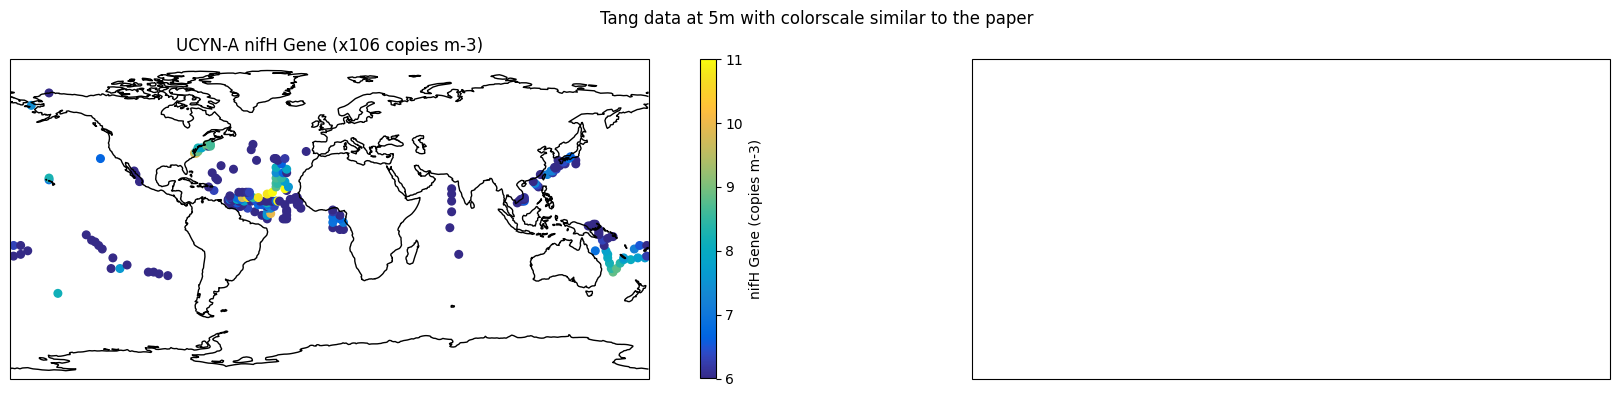

,LONGITUDE,LATITUDE,UCYN-A nifH Gene (x106 copies m-3),DEPTH (m)
count,21.000000,21.000000,21.000000,21.0
mean,85.523810,-60.571429,-0.516857,0.0
std,46.735018,9.431709,0.572250,0.0
min,36.000000,-69.000000,-1.000000,0.0
25%,39.000000,-68.000000,-1.000000,0.0
50%,69.000000,-66.000000,-1.000000,0.0
75%,110.000000,-55.000000,0.124000,0.0
max,152.000000,-40.000000,0.220000,0.0


In [16]:
plotColsOnMap(
    ["UCYN-A nifH Gene (x106 copies m-3)"],tang_nifh_final,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Tang data at 5m with colorscale similar to the paper",
    s=30
)
shio_final.describe()

In [17]:
shio_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 1 to 21
Data columns (total 4 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   LONGITUDE                           21 non-null     int64  
 1   LATITUDE                            21 non-null     int64  
 2   UCYN-A nifH Gene (x106 copies m-3)  21 non-null     float64
 3   DEPTH (m)                           21 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 804.0 bytes


# Combining all of them together into 1
Since both datasets have been cleaned and prepared, we can finally try joining them together into a single table that we can later combine with environmental data and train the model.

In [18]:
#final data columns that we intend to keep
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

#final_datasets=[dzdb_2024_nifh_final, maredat_nifh_final, tang_nifh_final, shio_final] #this is max list with available data
final_datasets=[tang_nifh_final, shio_final]

#the stats are printed out
print("Joining {0} datasets:".format(len(final_datasets)))
for i in range(len(final_datasets)):
    print(" - Dataset {0}: {1} rows loaded".format(i, len(final_datasets[i])))
print("")

#the data is joined
combined_df = pd.concat(final_datasets)
combined_len= len(combined_df)
print("Final dataset has {0} entries\n".format(combined_len))

combined_df.info()

Joining 2 datasets:
 - Dataset 0: 1820 rows loaded
 - Dataset 1: 21 rows loaded

Final dataset has 1841 entries

<class 'pandas.DataFrame'>
Index: 1841 entries, 0 to 21
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  1841 non-null   int64  
 1   LATITUDE                                   1841 non-null   int64  
 2   DEPTH (m)                                  1841 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  1539 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         1754 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1563 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 100.7 KB


## Checking for duplicates

This is done as datasets might overlap and we want to reduce overfitting. Large numbers could indicate a high chance of overfitting.

When running the function found 1517 dublicate rows. This means that some datasets overlap and should be removed.

In [19]:
print("Duplicate rows found: {0}".format(sum(combined_df.duplicated(bact_cols+cordinates_cols))))

combined_unique = combined_df.drop_duplicates(subset=bact_cols+cordinates_cols)

print("Duplicate rows found after drop: {0}\n".format(sum(combined_unique.duplicated(bact_cols+cordinates_cols))))

combined_unique.info()

Duplicate rows found: 38
Duplicate rows found after drop: 0

<class 'pandas.DataFrame'>
Index: 1803 entries, 0 to 21
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  1803 non-null   int64  
 1   LATITUDE                                   1803 non-null   int64  
 2   DEPTH (m)                                  1803 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  1519 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         1716 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1542 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 98.6 KB


## Replacing ND values with a random value close to 0

In [20]:
if not imputeRandom:
    #now we set the ND values that are not set to a noisy 0
    setND(combined_unique, bact_cols)

combined_unique.info()

Imputing ND values with uniform random distribution between 1e-06 and 0.01
<class 'pandas.DataFrame'>
Index: 1803 entries, 0 to 21
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LONGITUDE                                  1803 non-null   int64  
 1   LATITUDE                                   1803 non-null   int64  
 2   DEPTH (m)                                  1803 non-null   int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)  1519 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)         1716 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1542 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 98.6 KB


## Saving results
All bacterial data is saved into a file for later use.

In [21]:
#save the data
combined_unique.to_csv("../csv/features/bact_data.csv", index=False)

# VISUALIZATIONS

After joining them together we want to plot the distributions in the resulting data.*bact_cols* list all columns that contain bacterial data, that we want to show.

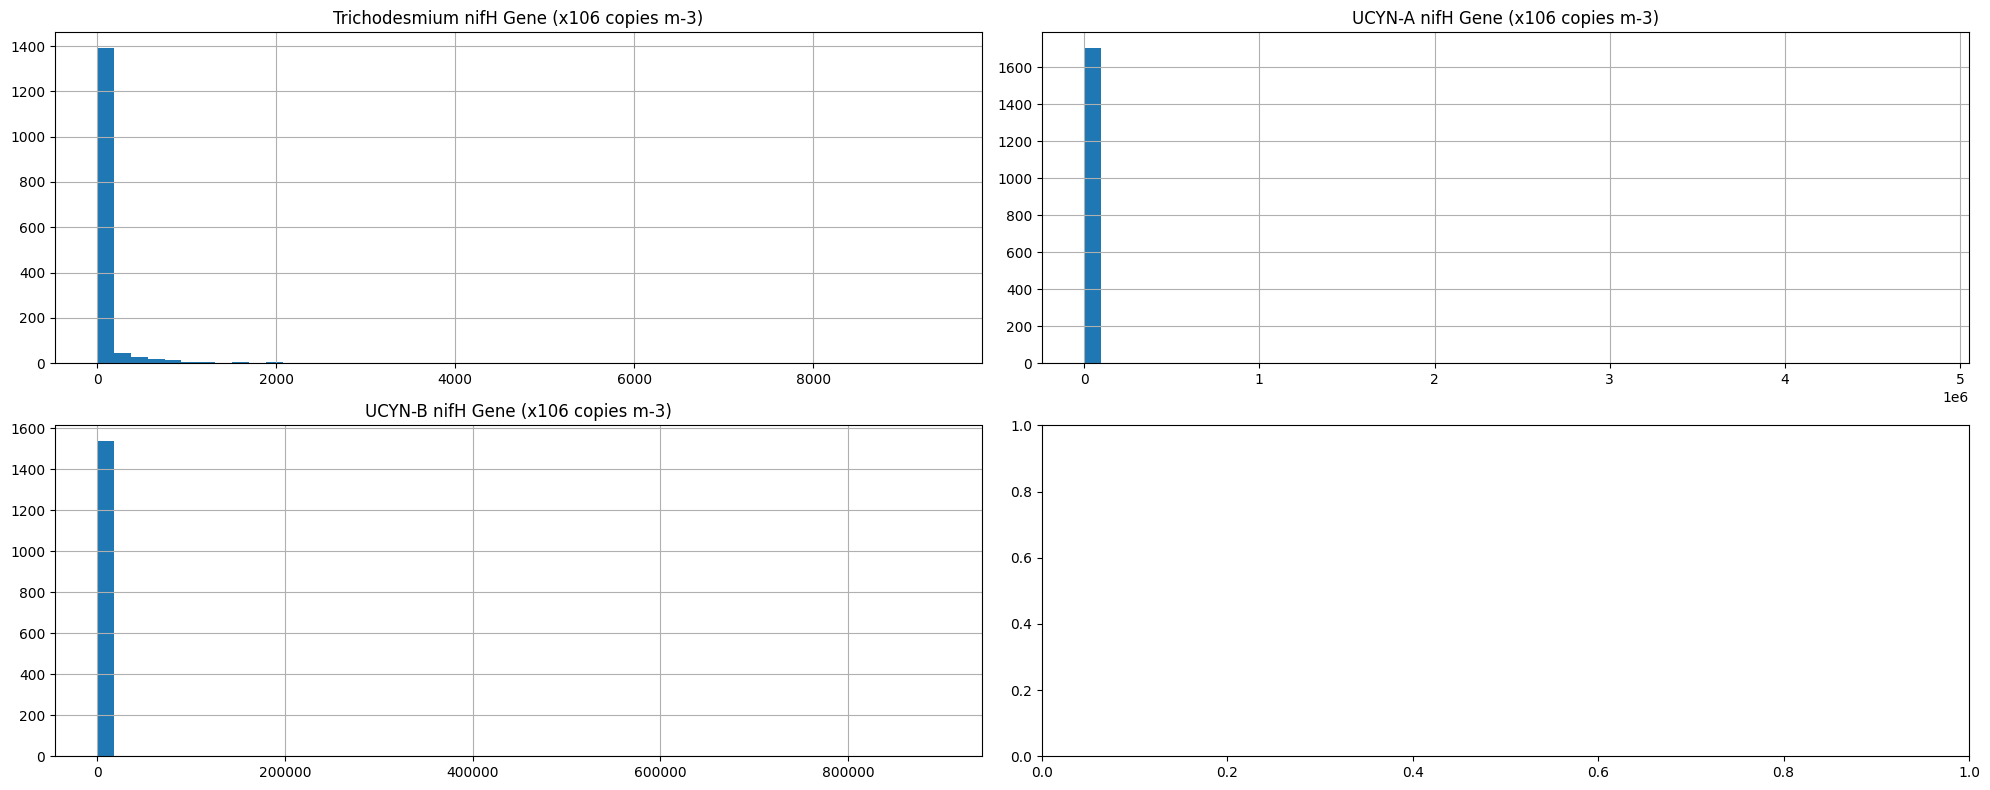

In [22]:
histCols(bact_cols, combined_unique)

We know from plotting data on a map and the initial plots in the paper, that the authors multiplied it by $10^6$ and plotted on a logarithmic scale. So, I wanted to try multiplication and then taking the logorithm to see the possible results.

0.0
0.0
0.0


/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


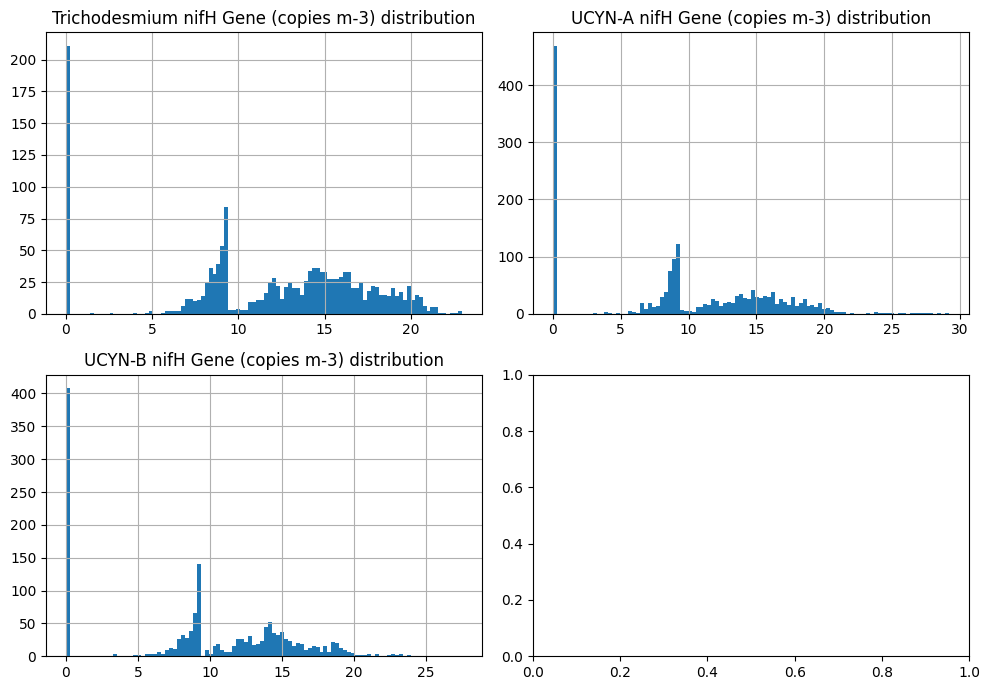

In [23]:
#another plot, but here the data is modified
figure, axis = plt.subplots(2, 2, figsize = (10,7))

#i want to see distributions of the points when we modify it
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]

    mod_ar = np.log(combined_unique[bact]*(10**6)+1)
    print(mod_ar.min())
    
    mod_ar.hist(bins=100,ax=ax)
    ax.set_title(title.replace("x106 ",""))

plt.tight_layout()
plt.show()

/home/tim/sidehustle/N2-fixers-in-the-ocean/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


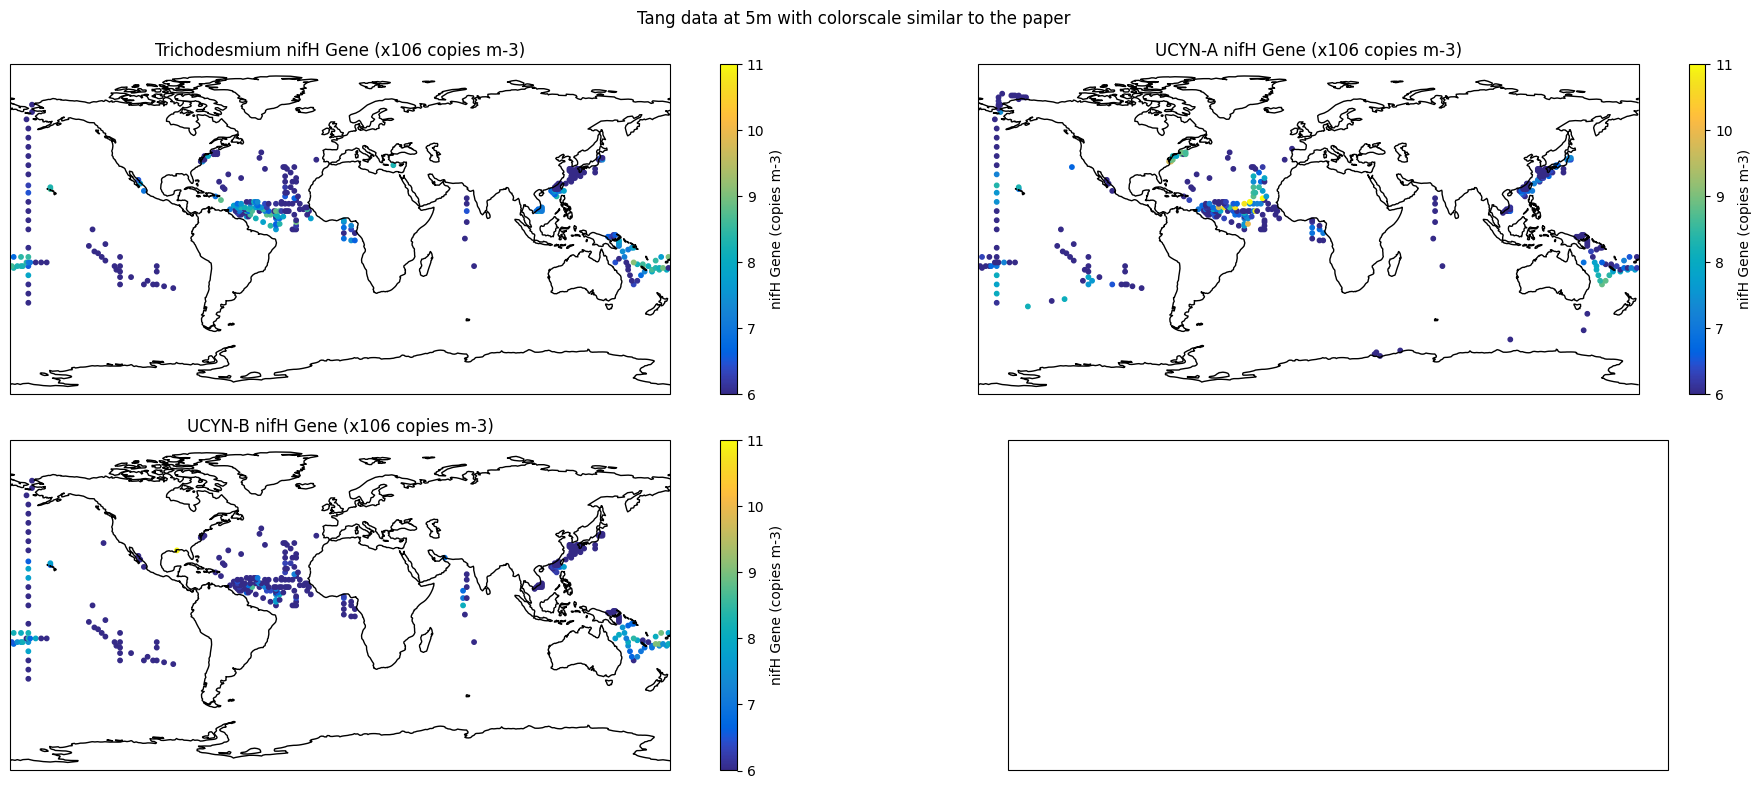

,LONGITUDE,LATITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,1841.000000,1841.000000,1841.000000,1539.000000,1.754000e+03,1563.000000
mean,9.637154,9.291146,51.840847,-106.694337,6.718892e+03,848.428508
std,123.470683,25.825122,87.954090,620.393123,1.357239e+05,24364.032796
min,-179.000000,-69.000000,0.000000,-1000.000000,-1.000000e+03,-1000.000000
25%,-91.000000,-15.000000,5.000000,0.000000,0.000000e+00,0.000000
50%,-24.000000,11.000000,26.000000,0.430000,0.000000e+00,0.010000
75%,126.000000,23.000000,75.000000,10.281000,2.837500e+00,1.723650
max,179.000000,74.000000,1700.000000,9413.540000,4.810000e+06,898000.000000


In [24]:
plotColsOnMap(
    bact_cols, combined_unique,
    constant=(10**6), 
    transf=(lambda x: np.log10(x+10)),
    min_lim=6,
    max_lim=11,
    cmap=parula_map,
    colorbar_label="nifH Gene (copies m-3)",
    title="Tang data at 5m with colorscale similar to the paper",
    s=10
)

combined_df.describe()